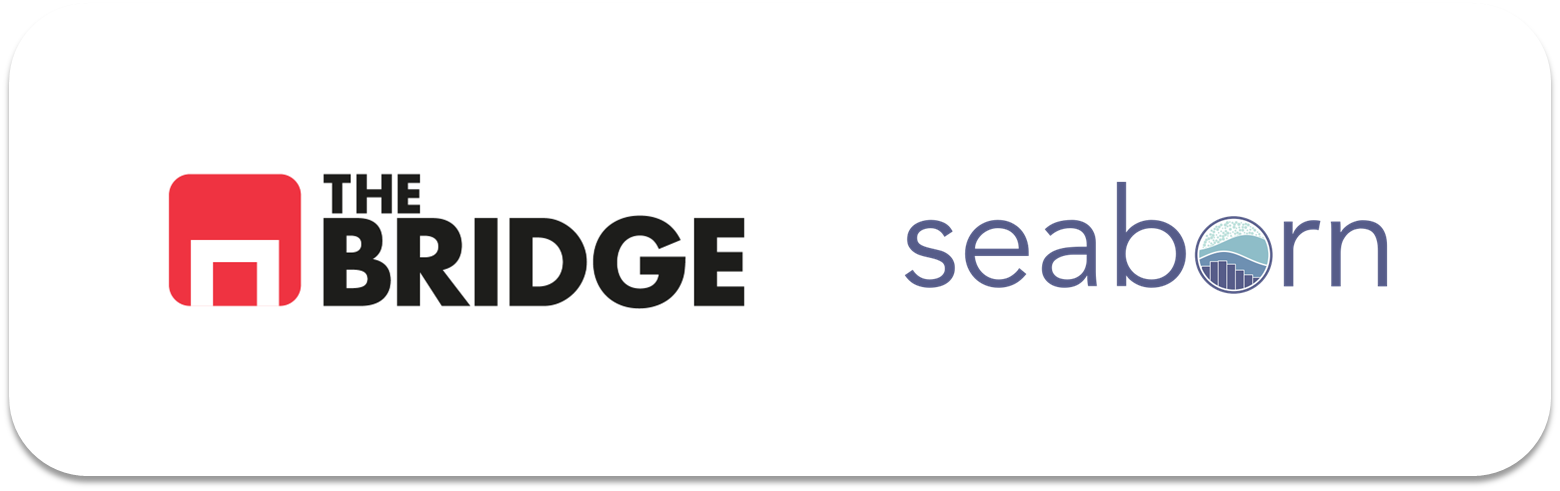

## PRACTICA OBLIGATORIA: **Visualización Avanzada y Presentación**

* La práctica obligatoria de esta unidad se divide en dos partes, una dedicada a visualización y construcción de funciones, y la otra a hacer una presentación de resultados. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## #1: Visualización

### #1.1

Carga el dataset de las ciudades de California que está en la ruta "./data/california_cities.csv". Muestra su contenido, deshazte de las filas con nulos.

In [2]:
df_cities = pd.read_csv("./data/california_cities.csv")
df_cities.head(20)

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
5,5,AlisoViejo,33.575000,-117.725556,127.0,417.0,47823,7.472,7.472,0.000,19.352,19.352,0.000,0.00
6,6,Alturas,41.487222,-120.542500,1332.0,4370.0,2827,2.449,2.435,0.014,6.342,6.306,0.036,0.57
7,7,AmadorCity,38.419444,-120.824167,280.0,919.0,185,0.314,0.314,0.000,0.813,0.813,0.000,0.00
8,8,AmericanCanyon,38.168056,-122.252500,14.0,46.0,19454,4.845,4.837,0.008,12.548,12.527,0.021,0.17
9,9,Anaheim,33.836111,-117.889722,48.0,157.0,336000,50.811,49.835,0.976,131.600,129.073,2.527,1.92


In [3]:
# Elimino las filas con nulos
df_cities.dropna(inplace=True)

### #1.2

Crea una función similar a la que se pide en el ejercicio 6 de la segunda tanda de ejercicios del workout. Es decir, una función para pintar diagramas de dispersion que tenga seis argumentos, pero ojo al cambio en el quinto:
1. Un dataframe
2. Una columna numérica del dataframe
3. Una columna numérica del dataframe diferente a la anterior.
4. Un columna categórica (Opcional, valor por defecto None)
5. Un valor para el tamaño de los puntos o una cadena, pero que puede ser una cadena de caracteres, en cuyo caso se debe interpretar como una de las columnas del dataframe cuyos valores deben controlar el tamaño
6. Un sexto argumento "escala", que permita manipular la escala del tamaño en el caso de que el quinto argumento sea una cadena. Este argumento multiplicará a los valores de la columna indicada en el parámetro anterior (así si quiero dividir por 10000, este sexto argumento tendrá que valer 1/10000)

La función debe pintar el diagrama de dispersión de la columna numérica 1, en el eje X, frente a la columna numérica 2, en el eje Y, usando un código de colores en función de la columna categórica y con el tamaño de los puntos según el argumento correspondiente. 

Si no se diera una columna categórica como argumento, el color no debe pasarse como parámetro a la función de Seaborn o Matplotlib que uses.

EXTRA: Añade un argumento que controle si la función pinta una leyenda para colores y tamaños o un colorbar y una leyenda para los tamaños. NO TE PREOCUPES POR EL FORMATO DE LA LEYENDA (lo veremos en la sesión en vivo)

In [4]:

# df: Dataframe
# colnum1 = Columna numérica 1
# colnum2 = Columna numérica 2
# colcat = Columna categórica para el color
# size = para el tamaño de los puntos
# scale = para el escalado
# colorbar = para pintar un colorbar o la leyenda estándar
# figsize = para el tamaño de la imagen
def dispersion(df, colnum1, colnum2, colcat=None, size=None, scale=None, colorbar=False, figsize=None):
    
    # Verificamos las columnas
    if not pd.api.types.is_numeric_dtype(df[colnum1]):
        raise TypeError(f"La columna {colnum1} no es numérica")
    
    if not pd.api.types.is_numeric_dtype(df[colnum2]):
        raise TypeError(f"La columna {colnum2} no es numérica")
    
    # Copiamos el df pq si tenemos que escalarlo no queremos modificar el original
    df_copy = df.copy()

    # Parámetros fijos de scatterplot
    params = dict(x=colnum1, y=colnum2, data=df_copy)
    
    # Valor por defecto del rango de sizes
    sizes = (20, 200)

    # Si tenemos columna para el color
    if colcat is not None:
        params["hue"] = colcat
        params["palette"] = "viridis"

    # Si tenemos columna para el tamaño
    if size is not None:
        params["size"] = size

        # Si hay escala
        if scale is not None:
           if not isinstance(size, int):
             sizes = (20 * scale, 200 * scale)
             params["sizes"] = sizes
               
    # Si queremos ver el colorbar escondemos la leyenda estándar
    if colorbar:
        params["legend"] = False

    # Inicializamos la figura
    fig, axs = plt.subplots(figsize=figsize)
    params["ax"] = axs   
    
    # Hacemos el diagrama de dispersión
    sns.scatterplot(**params)
    
    if colorbar:
        #Colorbar
        norm = plt.Normalize(df_copy[colcat].min(), df_copy[colcat].max())
        sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)

        plt.colorbar(sm, ax=axs, label="log$_{10}$(pop)")

        #Leyenda tamaños
        if size is not None and not isinstance(size, int):

            # Para la leyenda de tamaños he creado una lista de 6 valores equidistantes
            # entre el min y el max de la columna size
            vmin = df_copy[size].min()
            vmax = df_copy[size].max()
            areas = np.linspace(int(vmin), int(vmax), 6).astype(int)

            for area in areas:
                # Buscando por internet he visto que esta es la fórmula que usa
                # sns.scatterplot para deducir el tamaño de los puntos
                s = sizes[0] + (sizes[1] - sizes[0]) * (area - vmin) / (vmax - vmin)

                plt.scatter([], [], c="k", alpha=0.3, s=s, label=str(area) + " Km$^2$")
                plt.legend(title="Área (Km$^2$)")
    
    plt.show()

    


### #1.3

Pinta el diagrama de dispersión de longitud y latitud (longitud en las x, latitud en las y) de las ciudades, usando el tamaño de las ciudades para el tamaño de los puntos y los colores para mostrar la población. Previamente crea una columna nueva "log_poblacion" y asignale el log decimal de la poblacion (np.log10() y como argumento los valores de la columna "population_total"). Usa "log_poblacion" para el color.

In [5]:
# Columna log_poblacion
df_copy = df_cities.copy()
df_copy["log_poblacion"] = np.log10(df_copy["population_total"])


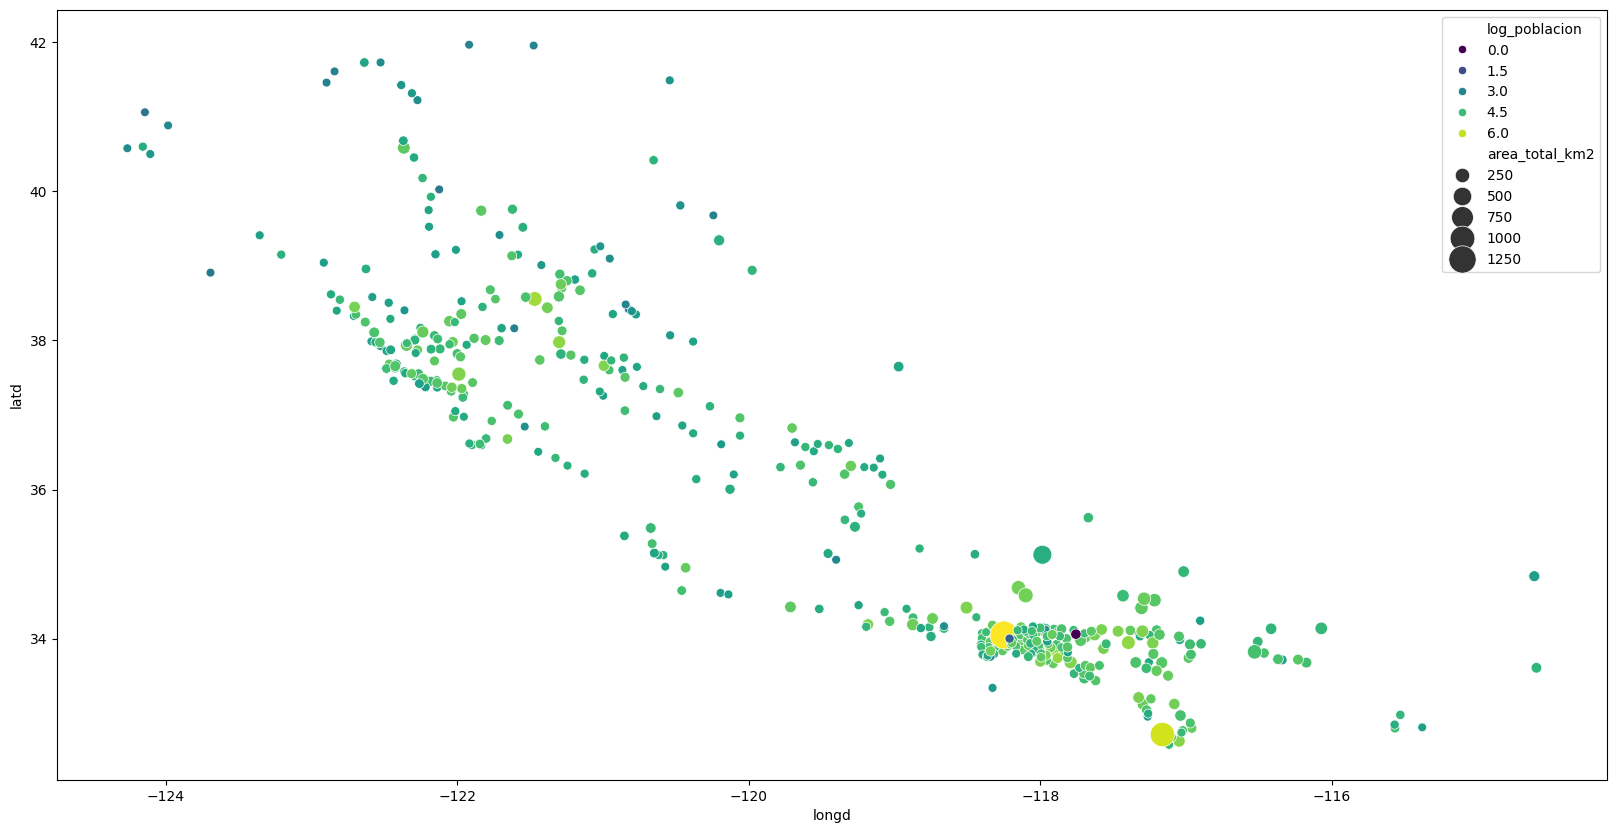

In [6]:
# Llamamos a la función para hacer el plot
dispersion(df=df_copy, colnum1="longd", colnum2="latd", colcat="log_poblacion", scale = 2 , size="area_total_km2", figsize=(20, 10))

Un ejemplo de como podría salir para que lo tengas de referencia: (olvidate de la leyenda, auque si quieres como extra puedes intentar ver cómo crearla así)

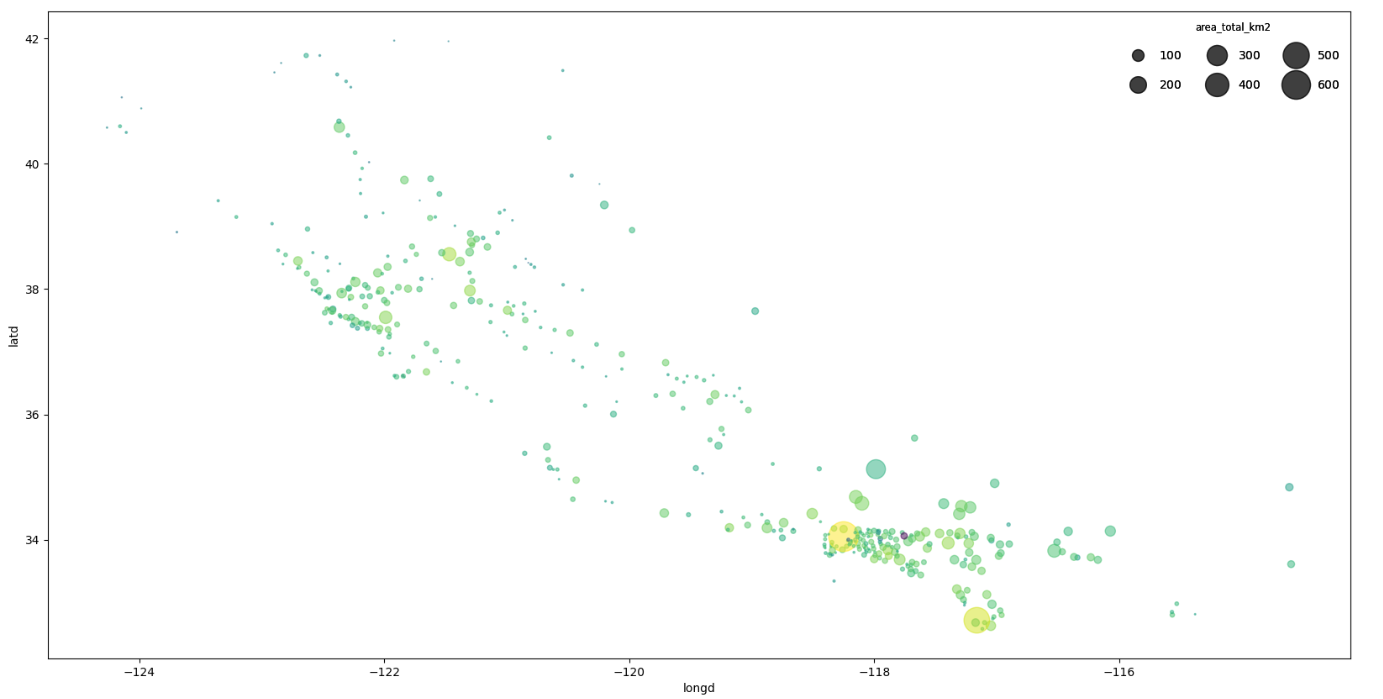

## #2: Presentación

En esta parte tendrás que hacer dos cosas:

#2.1 Crear una presentación sencilla sobre el Titanic de no más de 6 slides, sin incluir portada, con los siguientes mensajes y su apoyo en datos:  

1. El titanic fue un accidente con una tasa de mortalidad alta.  

2. Los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3. ...la clase en la que viajases tuvo una influencia significativa y podría explicar...  
4. ...las diferencias entre tasas de supervivencia de mujeres y niños.    
5. Además, aunque el puerto de embarque parece tener influencia, se podría asumir que más bien fue la clase de pasaje que embarcó en cada uno de ellos.  

#2.2 Las gráficas a emplear en la presentación debes generarlas en un notebook.  

Tienes que entregar ambas cosas: presentación y notebook :)

In [7]:
df_titanic = pd.read_csv("./data/titanic.csv")

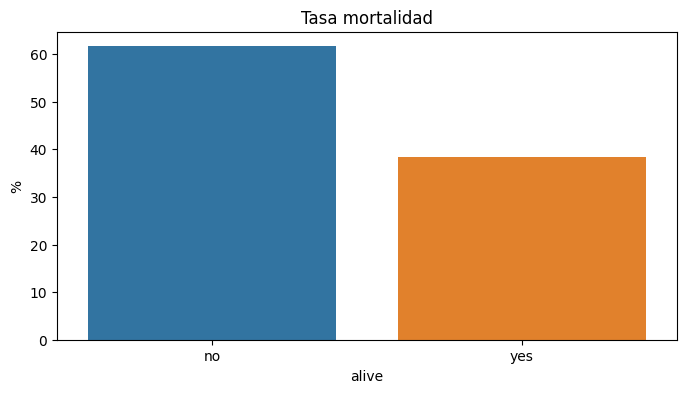

In [8]:
#1. El titanic fue un accidente con una tasa de mortalidad alta.  

# Visualizamos la variable alive
# Normalizamos los datos
data = df_titanic["alive"].value_counts(normalize=True) * 100

fig,ax = plt.subplots(figsize=(8,4))

sns.barplot(x = data.index, y = data.values, hue = data.index, ax=ax)

ax.set_title("Tasa mortalidad")
ax.set_ylabel("%")
fig.savefig("./img/Titanic01.png")

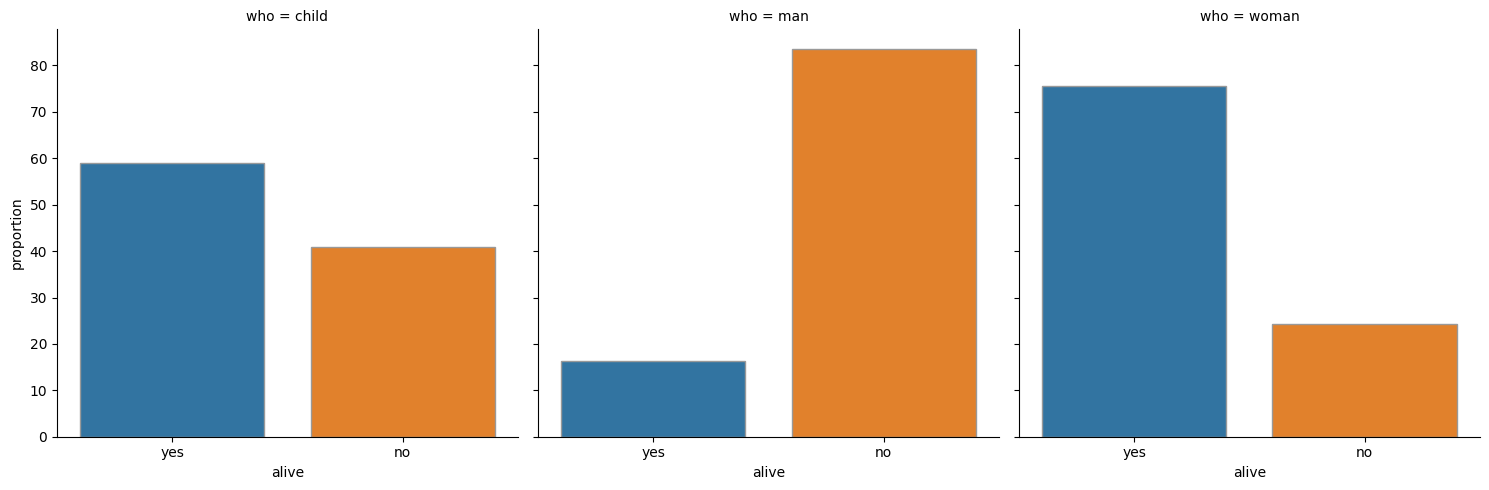

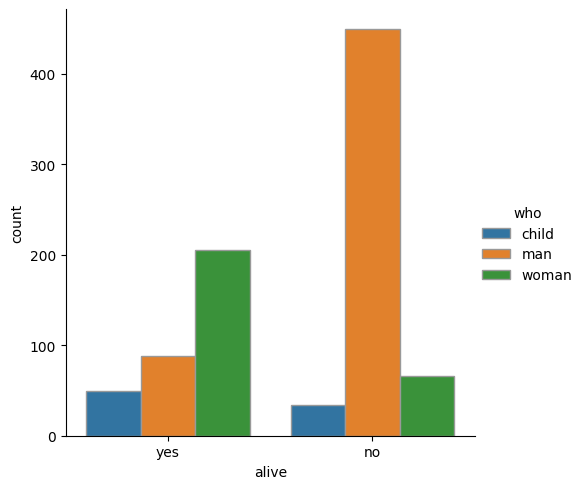

In [9]:
# 2. Los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  

def catplot_rel(df, catx, caty):
    frel = df.groupby(caty, as_index=False)[catx].value_counts(normalize=True)
    frel["proportion"] *= 100

    sns.catplot(x=catx,
                y="proportion",
                col=caty,
                hue = catx,
                kind="bar", 
                edgecolor=".6",
                data=frel);

catx = "alive"
caty = "who"

catplot_rel(df_titanic, catx, caty)

g = sns.catplot(x="alive", hue="who", kind="count", edgecolor=".6", orient = 'V', data = df_titanic.sort_values("who"));
g
g.savefig("./img/titanic_who_alive.png")



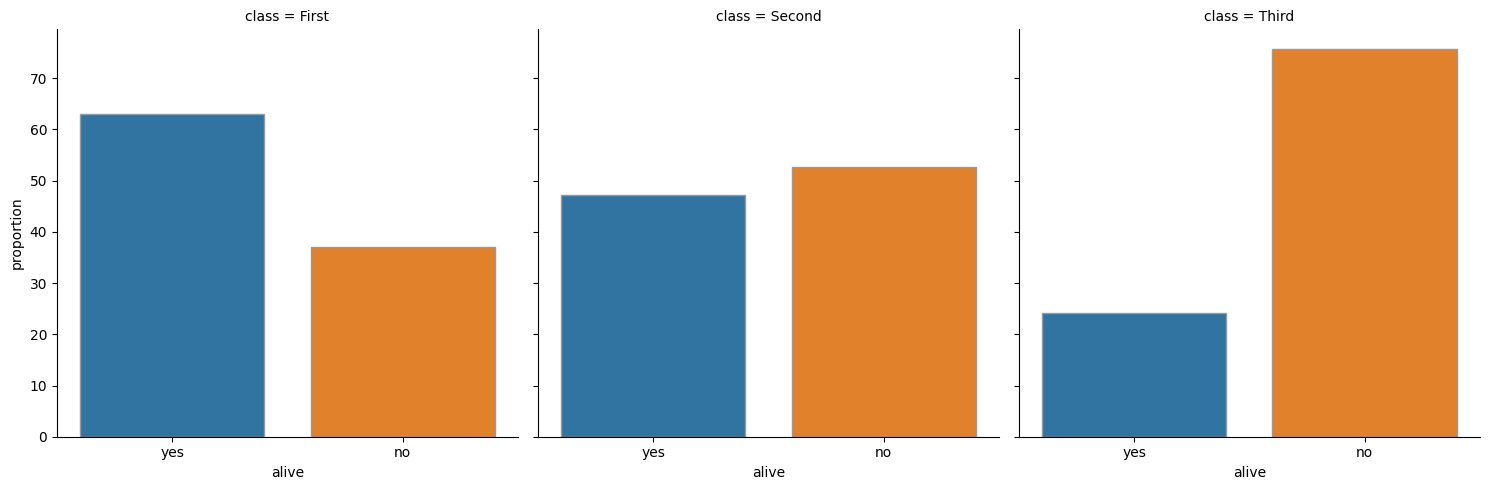

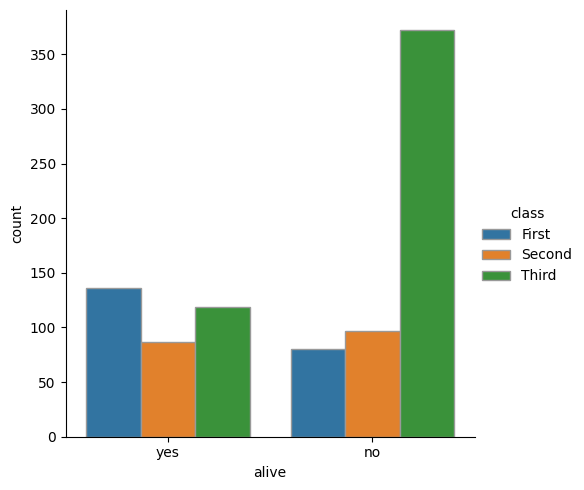

In [10]:
# 3. ...la clase en la que viajases tuvo una influencia significativa y podría explicar...  
# 4. ...las diferencias entre tasas de supervivencia de mujeres y niños.    
catx = "alive"
caty = "class"

catplot_rel(df_titanic, catx, caty)
g = sns.catplot(x=catx, hue=caty, kind="count", edgecolor=".6", orient = 'V', data = df_titanic.sort_values(caty));
g
g.savefig("./img/titanic_class_alive.png")

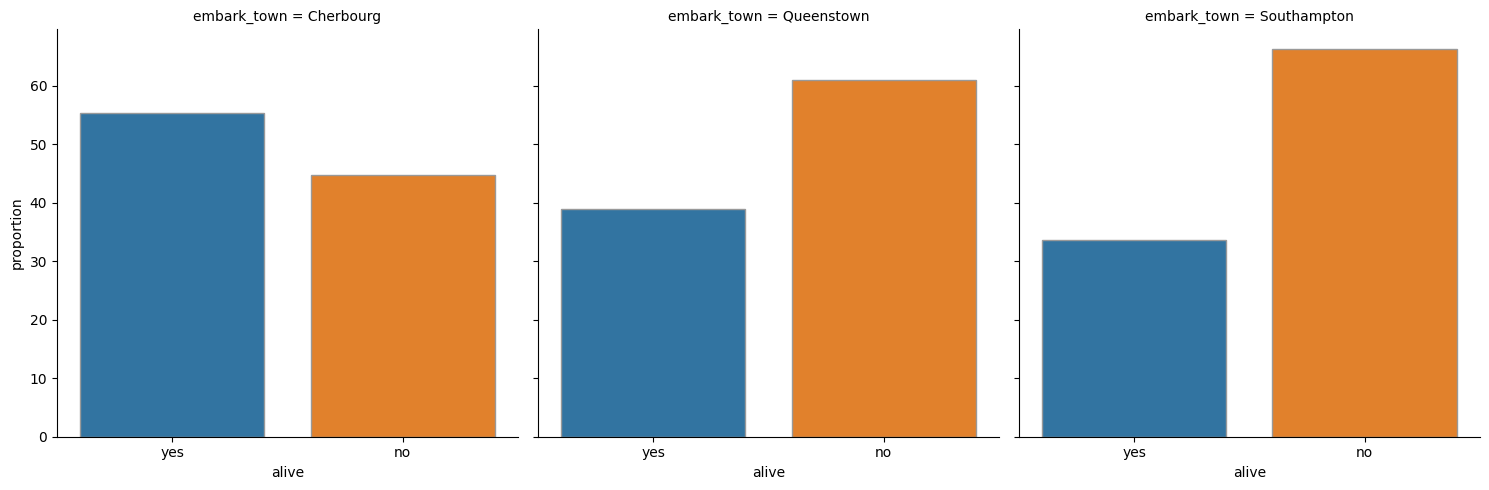

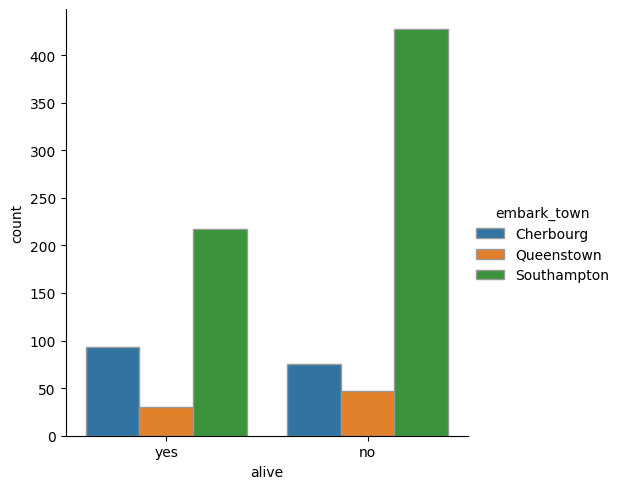

In [11]:
# 5. Además, aunque el puerto de embarque parece tener influencia, 
catx = "alive"
caty = "embark_town"

catplot_rel(df_titanic, catx, caty)
g = sns.catplot(x=catx, hue=caty, kind="count", edgecolor=".6", orient = 'V', data = df_titanic.sort_values(caty));
g
g.savefig("./img/titanic_embark_town_alive.png")


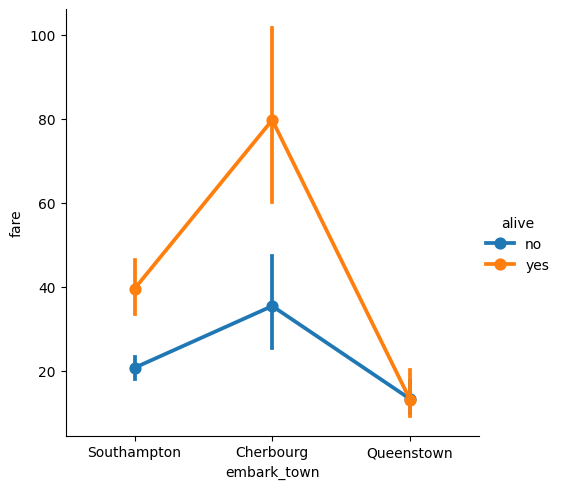

In [12]:
# se podría asumir que más bien fue la clase de pasaje que embarcó en cada uno de ellos.  
g = sns.catplot(x = "embark_town", y = "fare", hue = "alive", data = df_titanic, kind = "point");
g
g.savefig("./img/titanic_fare_alive_embark_town.png")